# CV Screener — исследование: ретрив тулами против «всё в промпт»

В `CLAUDE.md` записано архитектурное правило: агент достаёт данные тулами и никогда не получает
весь датасет в промпт. Ноутбук проверяет это правило измерениями, а не декларацией, и заодно
меряет, насколько устойчив сам агент.

Четыре раздела:

1. **Тулы против контекста** (часть 1 задания) — два арма на одних и тех же 9 кейсах из
   `evals/cases.json`, один чекер, 3 повтора. Цена, задержка, доля прохождений. Плюс замер того,
   как растёт промпт при росте коллекции.
2. **Лидерборд бесплатных моделей** (часть 4) — тот же агент на шести free-моделях OpenRouter,
   по одной, без фолбэка.
3. **Стабильность агента** (часть 2) — разброс между повторами плюс пять прогонов из `NOTES.md`.
4. **Внешний бенчмарк JobResQA** (часть 3) — та же пара армов на чужих резюме, с LLM-судьёй.

Все числа собраны реальными вызовами через OpenRouter и лежат в `research/results/*.json`.
Ноутбук читает только кэш: выполнение сверху вниз не тратит ни одного запроса. Сбор данных —
отдельная команда, `uv run python -m research.collect part1|part4|part3`. Логика в пакете
`research/`, ячейки только вызывают её, как `demo.ipynb` вызывает `cv_screener`.

Модели бесплатные и нестабильные: 429, пустые `choices`, разброс по времени в разы. Это видно
в числах ниже и это часть результата, а не шум, который надо было вычистить.

### Что урезала квота

Посреди сбора закончился суточный лимит OpenRouter на бесплатные модели — 1000 запросов на
аккаунт, общий для всех моделей, сброс в 00:00 UTC. Что из этого следует, по пунктам:

- **Раздел 1 собран полностью**, до лимита: 9 кейсов × 3 повтора × 2 арма = 54 прогона. Это
  главный результат, и он не урезан.
- **Раздел 2 (лидерборд)**: вместо 6 моделей × 2 повтора — 5 моделей, и повторов неровно: две
  модели успели по 2, остальные по 1. Шестая, `thinkingmachines/inkling:free`, не измерена вовсе.
  Число прогонов у каждой модели стоит в таблице отдельной колонкой, чтобы это было видно.
- **Раздел 4 (JobResQA)**: уменьшен с 13 резюме / 21 вопроса до 10 / 12, по одному повтору на арм.
- Прогоны, убитые суточным лимитом, **не считаются провалами модели**. Они распознаются по тексту
  ошибки, выбрасываются из кэша и перепрогоняются после сброса; в таблицах их нет ни в
  знаменателе, ни в колонке ошибок.
- Расход по запросам печатает ячейка ниже: отдельно до сброса и отдельно после, где действовал
  жёсткий потолок в 150 запросов, чтобы на утро осталась квота на демо.

In [1]:
from cv_screener.generate.generator import load_all
from cv_screener.llm import estimate_tokens
from research import cache, harness, history, jobresqa, plots, scaling, stats
from research.collect import DROPPED_MODELS, LEADERBOARD_MODELS
from research.tables import table

FORCE = False  # collection is a separate command: uv run python -m research.collect part1

part1_all = cache.load("part1_runs")
part4 = cache.load("part4_runs")
part3 = cache.load("part3_runs")
candidates = load_all()

# Reps 1-3 exist for both arms and are the A/B comparison; any extra reps were collected for
# arm A only (stability, section 3) and would bias the comparison, so they are held back here.
part1 = [r for r in part1_all if r["rep"] <= 3]

print(f"part1 {len(part1)} paired runs ({len(part1_all)} incl. extra arm-A reps) | "
      f"part4 {len(part4)} runs | part3 {len(part3)} runs")
print(f"requests: {cache.pre_reset_spent()} before the daily reset + {cache.post_reset_spent()} "
      f"after (cap {cache.POST_RESET_LIMIT}) = {cache.spent()} of {cache.BUDGET_LIMIT} budgeted")
table([{"section": k, "requests": v} for k, v in sorted(cache.budget_breakdown().items())])

part1 54 paired runs (54 incl. extra arm-A reps) | part4 45 runs | part3 24 runs
requests: 218 before the daily reset + 149 after (cap 150) = 367 of 750 budgeted


section,requests
part1,97
part3,111
part4,156
smoke,3


## 1. Два способа ответить на вопрос

**Арм A** — агент из `agent/loop.py` как есть: системный промпт, три тула в формате function
calling, temperature 0.2, до 6 шагов цикла. Датасет в контекст не попадает, только то, что
вернули тулы.

**Арм B** — та же цепочка моделей и та же температура, тулов нет: `search_text()` всех 14
кандидатов склеены в один системный промпт, один вызов на вопрос. Правила в промпте те же,
минус всё про тулы: отвечать только по приложенным CV, при отсутствии совпадения сказать, что
никто не подходит.

```mermaid
flowchart LR
    Q[вопрос] --> A[Арм A: Agent.ask]
    Q --> B[Арм B: один вызов]
    A --> S1[system + TOOLS] --> M1[модель]
    M1 --> TC[tool_calls] --> IDX[(Chroma)] --> M1
    M1 --> R1[ответ]
    C[(14 CV: search_text)] --> S2[system + весь корпус] --> M2[модель] --> R2[ответ]
    B --> S2
    R1 & R2 --> CH[check из evals/run.py]
```

Чекер один и тот же, `check` из `evals/run.py`, поэтому вердикты сопоставимы с прогонами в
`NOTES.md`. Две поправки в пользу арма B: снято требование «хотя бы один вызов тула» (тулов у
него нет по определению) и заземление считается истинным по построению — в промпте лежат все
кандидаты, назвать «недостанутого» он не может. Остаются `must_include`, `must_exclude`,
`expect_no_match`.

In [2]:
corpus = harness.corpus_text(candidates)
prompt = harness.baseline_prompt(corpus)
head = prompt[: prompt.index("=== CVs ===") + len("=== CVs ===")]
print(head)
print(f"... {len(candidates)} CVs, {len(corpus):,} chars\n")
print(f"arm B system prompt: ~{estimate_tokens(prompt):,} tokens, resent on every question")

You are a recruiting assistant answering questions about a dataset of candidate CVs.

The complete dataset is included below; it is the only information you have.

Rules:
1. Answer only from the CVs below; never guess or recall candidates from memory.
2. Name only candidates whose CV appears below, and cite what in their profile supports the
   answer (skills, role, years, languages with level).
3. If no CV below matches, say clearly that no one in the dataset matches. Do not invent or stretch.
4. "Senior" in a question means senior or above.
5. Be concise: a short answer with a bullet per candidate. Refer to people by name; never paste
   ids, JSON or citation markers into the answer.

=== CVs ===
... 14 CVs, 42,819 chars

arm B system prompt: ~10,886 tokens, resent on every question


### Что именно считается

Токены берутся из `usage` ответа провайдера и суммируются по всем вызовам внутри одного вопроса;
определения тулов входят в `prompt_tokens` арма A. Для этого в `llm.py` добавлен счётчик
`LLM.usage` (`requests`, `calls`, `prompt_tokens`, `completion_tokens`, `estimated_calls`) и
`reset_usage()`. Изменение обратно совместимое: сигнатура и поведение `chat()` прежние.

`requests` считает HTTP-попытки, включая ретраи и переходы по цепочке моделей, `calls` — только
удавшиеся. Если провайдер не вернул `usage`, вызов оценивается как длина в символах, делённая на
4, и помечается; сколько таких строк попало в выборку, видно в колонке `estimated rows`.

In [3]:
table(stats.arm_summary(part1), note="27 runs per arm = 9 cases x 3 repetitions")

arm,runs,pass rate,median prompt tok,median total tok,p95 total tok,median s,p95 s,tok / correct answer,LLM calls (median),errors,estimated rows
B: all CVs in the prompt,27,25/27 = 93%,10637,11042,11919,7.5,20.1,11947,1,0,0
A: tools (agent),27,26/27 = 96%,2712,2985,6187,7.8,31.2,3586,2,0,0


In [4]:
table(stats.per_question(part1))

case,A pass,A tok,A s,B pass,B tok,B s,models,failure reasons
no-match-cobol,3/3,2547,2.9,3/3,10777,6.9,nemotron-3-super-120b-a12b,
no-match-hebrew,3/3,2518,2.6,3/3,10821,4.3,nemotron-3-super-120b-a12b,
no-match-unknown-person,3/3,2495,10,3/3,10708,2.9,nemotron-3-super-120b-a12b,
portuguese-language,3/3,2903,3.8,3/3,11054,7.5,nemotron-3-super-120b-a12b,
python-skill,3/3,4279,5.6,3/3,11499,12.6,nemotron-3-super-120b-a12b,
senior-ml-fit,2/3,3261,12.3,1/3,10898,6.6,nemotron-3-super-120b-a12b,prompt: missing Rosalinda Barral; tools: missing Rosalinda Barral
spanish-language,3/3,4085,9.4,3/3,11144,6.4,nemotron-3-super-120b-a12b,
summarize-katie,3/3,6187,11.8,3/3,11514,18.7,nemotron-3-super-120b-a12b,
years-filter,3/3,2943,14.3,3/3,11075,14.7,"nemotron-3-super-120b-a12b, nemotron-3-ultra-550b-a55b",


### Что получилось

**Цена.** Медиана арма A — 2985 токенов на вопрос против 11042 у арма B, в 3.7 раза меньше; на
один правильный ответ 3586 против 11947. Разрыв целиком в промпте: 2712 против 10637 медианных
`prompt_tokens`. Арм A делает два вызова вместо одного и всё равно дешевле, потому что оба вызова
несут результаты поиска, а не датасет.

**Задержка.** По медиане разницы нет: 7.8 с против 7.5 с. Хвост хуже у арма A — p95 31.2 с против
20.1 с: два последовательных обращения к нестабильному free-эндпоинту дают два шанса попасть на
медленный ответ. Это ровно тот эффект, о котором пишут в «Token Tax of Epistemic Accuracy»
(ссылка в выводах): ретрив дешевле по токенам, но длинный контекст иногда быстрее по времени.
Наши данные с этим согласуются, и умолчать об этом было бы подгонкой.

**Качество.** 26/27 против 25/27 — разница в один прогон, на такой выборке это шум. Честный
вывод: на 14 резюме «всё в промпт» не хуже по качеству, и аргумент за тулы здесь про цену и
масштабирование, а не про точность.

**Падения.** Все три — один кейс `senior-ml-fit`: одно в арме A, два в арме B. Модель называла
только Katie Brown (principal NLP researcher, 15 лет), а `must_include` требует Rosalinda Barral.
При этом в самом кейсе написано «Katie Brown (principal) is acceptable too» — ожидание в
`cases.json` строже собственного комментария. Это дефект эвала, а не агента, и он того же рода,
что уже записан в `NOTES.md`: без повторных прогонов такие вещи не всплывают.

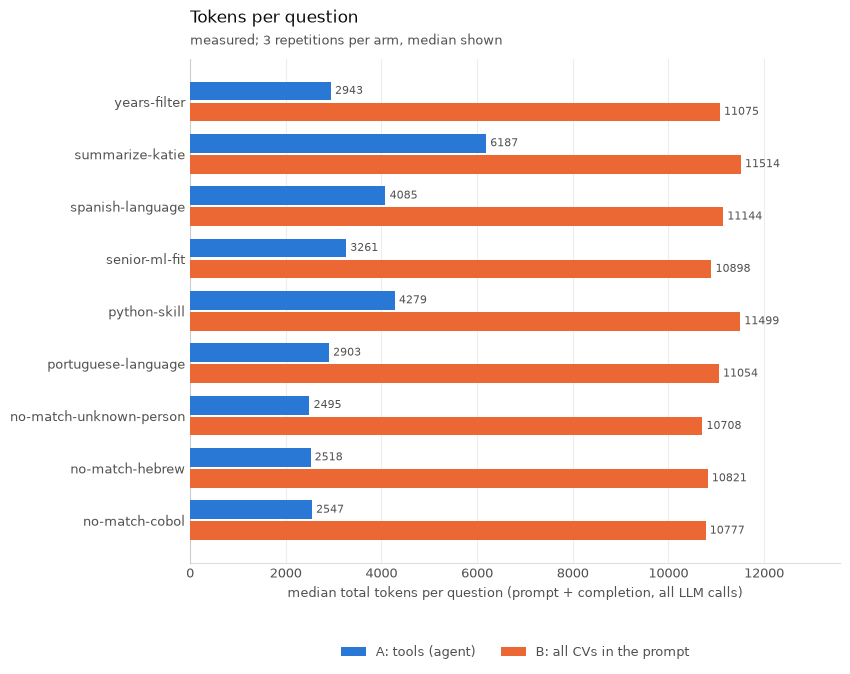

In [5]:
_ = plots.tokens_by_question(stats.per_question(part1))

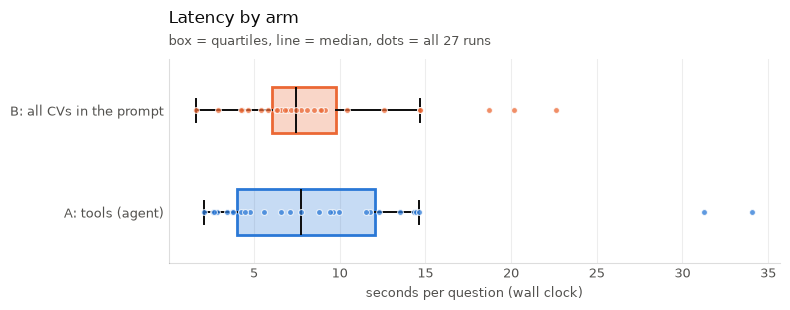

In [6]:
_ = plots.latency_by_arm(part1)

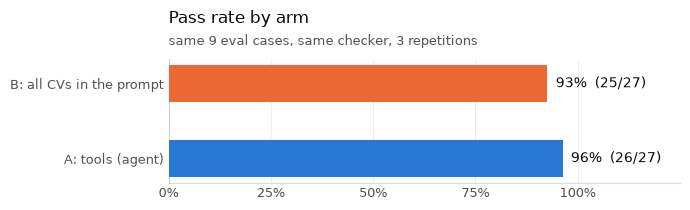

In [7]:
_ = plots.pass_rate_by_arm(part1)

### Масштабирование

Синтетические коллекции строятся дублированием 14 реальных кандидатов с возмущением копий (новая
личность из Faker, сдвинутый стаж, циклически сдвинутый список навыков), поэтому длина документа
остаётся реалистичной. Промпт арма B меряется в символах и переводится в токены оценщиком
chars/4; модели здесь не вызываются вообще.

Сначала оценщик калибруется. При N = 14 есть настоящее число от провайдера, и chars/4 можно
сравнить с ним напрямую — иначе вся кривая была бы словами, а не измерением.

In [8]:
measured_b = stats.median([r["prompt_tokens"] for r in part1 if r["arm"] == "prompt"])
measured_a = stats.median([r["prompt_tokens"] for r in part1 if r["arm"] == "tools"])
table([scaling.calibration(candidates, measured_b)], note="chars/4 against the provider's own count")
table(scaling.prompt_size_curve(candidates), note="computed, no LLM calls")

N,estimated (chars/4),measured (provider usage),estimate / measured
14,10894,10637,1.02


N documents,prompt chars,est. prompt tokens
14,43577,10894
50,153168,38292
100,307006,76752
200,611850,152962


Оценщик завышает на 2.4% относительно того, что посчитал провайдер на реальном промпте из 14 CV:
10894 против 10637. Ошибка на порядок меньше разницы между армами, значит кривой можно
пользоваться.

Дальше две линии разной природы, и на графике они помечены по-разному. Оранжевая — **вычисленная**:
промпт арма B растёт линейно, примерно 764 токена на документ, и на 200 резюме это ~153 тысячи
токенов в каждом вопросе. Синяя пунктирная — **измеренная** медиана арма A, 2712 токенов; она
горизонтальна не потому, что коллекция маленькая, а потому что тул отдаёт top-k, а k ограничен
двадцатью независимо от N.

Окно контекста здесь не главный предел. 32k пробивается где-то между 14 и 50 документами, 128k —
около 170, но платить и ждать за 150 тысяч токенов на каждый вопрос приходится задолго до того,
как модель откажется их принимать. Про деградацию качества при росте контекста с тем же объёмом
полезной информации — исследование Chroma «Context Rot», ссылка в выводах.

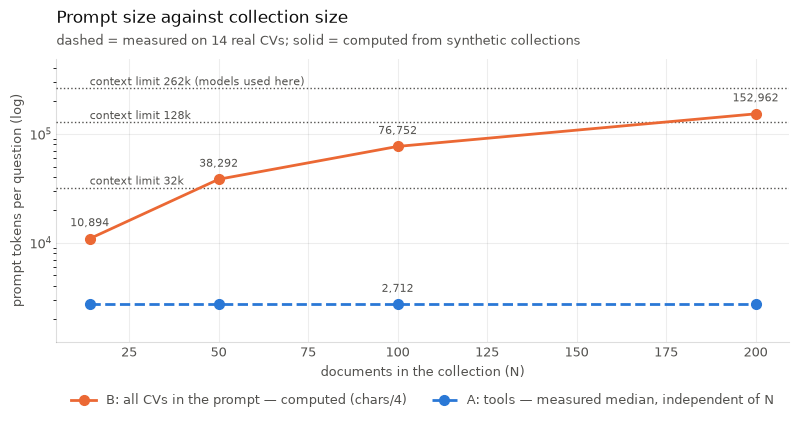

In [9]:
_ = plots.scaling(scaling.prompt_size_curve(candidates), measured_a, scaling.CONTEXT_LIMITS)

## 2. Лидерборд бесплатных моделей

Тот же агент (арм A), те же 9 кейсов, но модель одна и фолбэка нет:
`Settings(model=<id>, fallback_models=())`. Вернула пустой ответ или отказала по своей причине —
это её провал, а не повод переключиться на соседнюю. Кандидаты отобраны запросом к
`openrouter.ai/api/v1/models` по двум признакам: id оканчивается на `:free` и в
`supported_parameters` есть `tools`. Четыре из пяти — цепочка проекта из `.env`, пятая
(`qwen3.8-27b`) — самая крупная из оставшихся.

Планировалось 6 моделей × 2 повтора; квота урезала до 5 моделей с неровным числом повторов.
Смотреть надо на колонку `runs`: super отвечала 18 раз, ultra 12, nano 9, а gemma и qwen не
ответили ни разу — их провайдеры троттлили каждый запрос. Проценты между строками с разным
знаменателем сравниваются с поправкой на это. Это срез одного вечера на
бесплатном тарифе, а не рейтинг моделей.

**Про 429 отдельно.** У OpenRouter есть суточный лимит на бесплатные модели — 1000 запросов на
аккаунт со сбросом в 00:00 UTC, — и он общий для всех моделей сразу. Прогон, упавший в этот
лимит, ничего не говорит о модели: он говорит об аккаунте. Если засчитать его как провал модели,
лидерборд превратится в отчёт о том, в каком порядке модели опрашивались. Поэтому такие записи
распознаются по тексту ошибки (`free-models-per-day`), выбрасываются из кэша и перепрогоняются
после сброса, а сборщик останавливается после трёх подряд, чтобы не жечь бюджет впустую. В
таблице ниже только прогоны, которые реально дошли до модели, и колонка `errors` считает
настоящие отказы, а не исчерпанную квоту.

In [10]:
measured = {r["requested_model"] for r in part4}
print(f"{len(measured)} of {len(LEADERBOARD_MODELS)} shortlisted models measured")
for m in LEADERBOARD_MODELS:
    if m not in measured:
        print(f"  NOT MEASURED: {m} — cut by the account's daily cap, not a model failure")
for m in DROPPED_MODELS:
    print(f"  DROPPED from the shortlist: {m} — no quota left for a 6th model")
for row in stats.leaderboard(part4) if part4 else []:
    print(f"  {row['runs']:2d} runs ({row['runs'] // 9} repetition(s)): {row['model']}")

5 of 5 shortlisted models measured
  DROPPED from the shortlist: thinkingmachines/inkling:free — no quota left for a 6th model
  18 runs (2 repetition(s)): nvidia/nemotron-3-super-120b-a12b:free
  12 runs (1 repetition(s)): nvidia/nemotron-3-ultra-550b-a55b:free
   9 runs (1 repetition(s)): nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
   3 runs (0 repetition(s)): google/gemma-4-31b-it:free
   3 runs (0 repetition(s)): qwen/qwen3.8-27b:free


In [11]:
board = stats.leaderboard(part4) if part4 else []
table(
    board,
    cols=["model", "runs", "passed", "pass %", "errors", "rate limits",
          "median tok", "median s", "median tool calls", "ungrounded"],
    note="sorted by pass rate, then median latency; errors counted as failures",
)

model,runs,passed,pass %,errors,rate limits,median tok,median s,median tool calls,ungrounded
nvidia/nemotron-3-super-120b-a12b:free,18,18/18,100%,0,0,2991,9.4,1,0
nvidia/nemotron-3-ultra-550b-a55b:free,12,12/12,100%,0,0,3194.5,15.1,1,0
nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free,9,3/9,33%,6,0,3797,28.3,1,0
google/gemma-4-31b-it:free,3,0/0,not measured,0,3,nan,nan,nan,0
qwen/qwen3.8-27b:free,3,0/0,not measured,0,3,nan,nan,nan,0


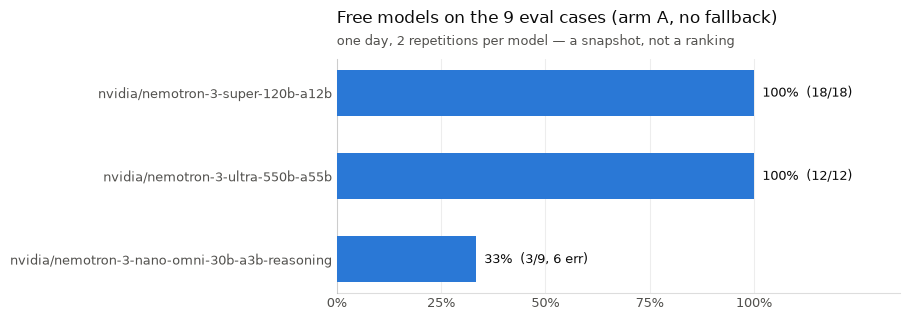

In [12]:
_ = plots.leaderboard(board) if board else print("no cached part4 runs")

PLACEHOLDER_LEADERBOARD_READING

## 3. Стабильность агента

Разброс между повторами берётся из тех же прогонов арма A: 3 повтора × 9 кейсов. К ним
добавлены пять прогонов, уже записанных в `NOTES.md`. Прогоны 1 и 2 там напечатаны построчно, у
прогонов 3–5 указан только падавший кейс и итог, поэтому число тулов для остальных кейсов —
«не записано», а не ноль.

In [13]:
tools_runs = [r for r in part1_all if r["arm"] == "tools"]  # every repetition, not just 1-3
reps = max(r["rep"] for r in tools_runs)
table(stats.case_stability(tools_runs), note=f"arm A, {reps} repetitions per case, this notebook")

case,runs,passed,pass rate,tool calls,median tool calls,s (median),models
no-match-cobol,3,3,100%,1–1,1,2.9,nvidia/nemotron-3-super-120b-a12b:free
no-match-hebrew,3,3,100%,1–1,1,2.6,nvidia/nemotron-3-super-120b-a12b:free
no-match-unknown-person,3,3,100%,1–1,1,10,nvidia/nemotron-3-super-120b-a12b:free
portuguese-language,3,3,100%,1–1,1,3.8,nvidia/nemotron-3-super-120b-a12b:free
python-skill,3,3,100%,1–1,1,5.6,nvidia/nemotron-3-super-120b-a12b:free
senior-ml-fit,3,2,67%,1–1,1,12.3,nvidia/nemotron-3-super-120b-a12b:free
spanish-language,3,3,100%,1–1,1,9.4,nvidia/nemotron-3-super-120b-a12b:free
summarize-katie,3,3,100%,2–2,2,11.8,nvidia/nemotron-3-super-120b-a12b:free
years-filter,3,3,100%,1–1,1,14.3,"nvidia/nemotron-3-super-120b-a12b:free, nvidia/nemotron-3-ultra-550b-a55b:free"


In [14]:
table(history.summary(), note="five runs transcribed from NOTES.md; see research/history.py")

case,historical runs,passed,tool calls (recorded),tool-call samples
python-skill,5,3,1–6,4
spanish-language,5,5,1–1,2
senior-ml-fit,5,5,1–3,2
summarize-katie,5,5,2–2,2
portuguese-language,5,5,1–1,2
years-filter,5,5,1–1,2
no-match-hebrew,5,5,1–1,2
no-match-cobol,5,5,1–1,2
no-match-unknown-person,5,5,1–2,2


В этих 27 прогонах агент ведёт себя ровнее, чем в прогонах из `NOTES.md`: число вызовов тулов не
плавало ни в одном кейсе — везде ровно 1, кроме `summarize-katie`, где стабильно 2
(`find_by_name`, затем `get_candidate`). Фан-аут из прогона 3, где модель дёрнула шесть тулов и
потеряла половину найденных людей, не повторился ни разу. Фикс, описанный в `NOTES.md` (навыки
внутри результатов поиска плюс запрет размножать `get_candidate`), держится.

Единственный нестабильный кейс — `senior-ml-fit`, 2 из 3, и это то же падение, что разобрано
выше: строгость эвала, а не поведение агента. В одном прогоне `years-filter` ответила вторая
модель цепочки — фолбэк сработал штатно и на вердикт не повлиял.

Исторические пять прогонов дают другую картину по `python-skill`: 3 из 5, разброс тулов 1–6. Оба
падения уже разобраны в `NOTES.md` и починены, и в текущих трёх прогонах кейс проходит 3 из 3.
Объединяя, по каждому кейсу набирается 8 прогонов, из них 3 с полной телеметрией; все падения за
эту историю приходятся на два кейса, и оба раза причина оказалась вне агента — в чекере, в данных
или в самой формулировке ожидания.

## 4. Внешний бенчмарк: JobResQA

[JobResQA](https://github.com/Avature/jobresqa-benchmark) (Avature, CC BY-SA 2.0,
[arXiv:2601.23183](https://arxiv.org/abs/2601.23183)) — 581 QA-пара к 105 синтетическим парам
«резюме + вакансия» на пяти языках, три уровня сложности. Берётся английский сплит; файл лежит в
`research/data/` и в git не попадает (`research/.gitignore`).

Резюме там — свободный текст с плейсхолдерами `[NAME]`, `[COMPANY]`, и в схему `Candidate` он не
ложится. Парсить его в схему значило бы подгонять чужие данные под свою модель, поэтому построен
отдельный временный коллекшн Chroma с сырым текстом и тем же локальным эмбеддером `FastEmbedder`,
а над ним — минимальный цикл с одним тулом `search_resumes`, возвращающим полный текст top-k
резюме. Арм B, как и раньше, кладёт все 13 резюме в один промпт.

Отбор детерминированный: выкинуты вопросы, опирающиеся на текст вакансии (второго документа у нас
нет), затем по квоте 5/4/3 берутся Basic / Intermediate / Complex, не больше двух вопросов на
резюме. Каждому резюме присвоено синтетическое имя (Faker, фиксированный seed) и подставлено
вместо `[NAME]`, чтобы вопрос указывал на конкретного человека.

Размер урезан: планировались 13 резюме и 21 вопрос, осталось 10 и 12, по одному повтору на арм.
Причина та же суточная квота; на такой выборке разница в один-два ответа — это уже проценты, и
читать её как значимую нельзя.

In [15]:
items, texts, names = jobresqa.select()
print(f"{len(items)} questions over {len(texts)} resumes; "
      f"corpus ~{estimate_tokens(jobresqa.corpus(texts, names)):,} tokens")
table(
    [{"complexity": it.complexity, "question": it.question[:88], "gold": it.gold[:46]}
     for it in items],
    note="questions as sent, after the name substitution",
)

12 questions over 10 resumes; corpus ~9,258 tokens


complexity,question,gold
Basic,Which format of client documentation has Joseph Brown produced?,Technical and business documentation experienc
Basic,Does Jeremiah Kirby have multi-platform customer service experience?,Limited platform diversity.
Basic,Would Justin Glass likely be able to contribute to a creative workplace?,Slighlty probable
Basic,What scale of event management experience does Jordan Matthews bring?,Extensive - managed 60+ annual events internat
Basic,How relevant is Jose Soto's experience with electrical wiring to network infrastructure?,Basic electrical knowledge present but limited
Intermediate,About Joseph Brown: What insight does the SAP mentorship role provide about coaching abi,Direct teaching experience with applied method
Intermediate,About Jeremiah Kirby: What insights from retail franchise customer service could enhance,Relevant inventory and transaction management
Intermediate,What skills does Justin Glass have according to their experience as a retail professiona,Customer service
Intermediate,How has Jordan Matthews's budget management experience evolved through different roles?,Progressive budget responsibility growth.
Complex,About Jose Soto: What insights from machinery diagnostic testing could enhance network t,Systematic diagnostic approach transferable.


### Судья

Оценка бинарная, против поля `short_answer`, с однострочной причиной. Промпт судьи целиком:

In [16]:
print(jobresqa.JUDGE_SYSTEM)

You grade one answer to a question about a résumé.

Question: {question}
Reference answer: {gold}
Answer to grade: {answer}

The answer is CORRECT when it states the same fact as the reference, even if worded
differently, more verbosely, or with extra correct detail. It is INCORRECT when it contradicts
the reference, omits the fact the reference gives, or asserts a specific fact where the
reference is "Unknown".

Reply with exactly one line, no markdown:
CORRECT|<reason in under 15 words>
or
INCORRECT|<reason in under 15 words>


Ограничения судьи, без смягчений: это та же семья бесплатных моделей, что отвечает в армах, так
что systematic-ошибки могут коррелировать. Эталоны в Intermediate и Complex часто субъективны
(«Highly probable», «Greatly», «Progressive budget responsibility growth»), и согласие с ними —
вопрос трактовки, а не факта. Абсолютная точность поэтому читается хуже, чем разница между
армами: её судья видит в одинаковых условиях, одним и тем же промптом.

Плюс отдельная честная метрика, которая от судьи не зависит: `retrieval hit` — попало ли нужное
резюме в то, что вернул тул. У арма B она равна единице по построению.

In [17]:
table(jobresqa.accuracy_table(part3))
table(jobresqa.by_complexity(part3), note="correct answers per complexity level")

arm,questions,correct,accuracy,median tokens,median s,retrieval hit
A: retrieve top-k,12,8,0.67,5871,10.71,12/12
B: all résumés in prompt,12,7,0.58,8469,11.34,12/12


complexity,A correct,B correct
Basic,2/5,3/5
Intermediate,4/4,3/4
Complex,2/3,1/3


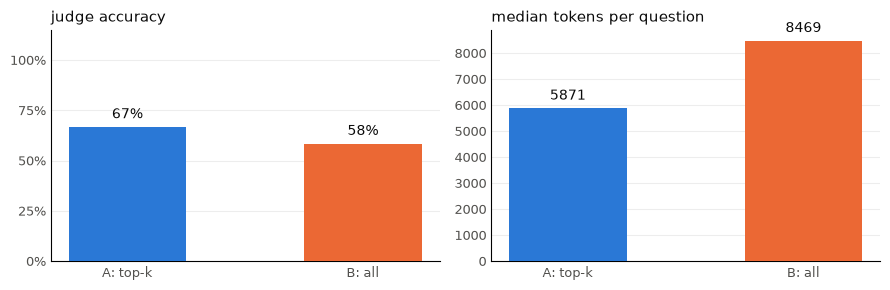

In [18]:
_ = plots.external_arms(jobresqa.accuracy_table(part3)) if part3 else print("no cached part3 runs")

PLACEHOLDER_PART3_READING

## Выводы

1. **Ретрив через тулы дешевле в разы и не дорожает с ростом коллекции.** Измерено: 2985 против
   11042 медианных токенов на вопрос, 3586 против 11947 на один правильный ответ. Вычислено:
   промпт «всё в контекст» растёт примерно на 764 токена за документ, и на 200 резюме это ~153
   тысячи токенов в каждом вопросе, тогда как измеренная медиана арма A остаётся 2712 при любом
   N: тул отдаёт top-k, k ограничен двадцатью.

2. **По качеству на 14 резюме разницы нет.** 26/27 против 25/27 — один прогон разницы, то есть
   шум. Продавать тулы как способ отвечать точнее было бы враньём: на этом размере это способ
   отвечать за те же деньги втрое дешевле, а на большем — единственный работающий способ.

3. **По задержке длинный контекст местами выигрывает.** Медианы почти равны, 7.8 против 7.5 с, но
   хвост у агента хуже: p95 31.2 против 20.1 с. Причина механическая — два последовательных вызова
   вместо одного, и каждый из них может попасть на медленный free-эндпоинт.

4. **Лидерборд — срез одного дня, не рейтинг.** Обе крупные Nemotron прошли все прогоны без
   фолбэка: super 120B 18/18, ultra 550B 12/12, медиана около 3 тысяч токенов, super в полтора раза
   быстрее (9.4 против 15.1 с). Nano-omni 30B ответила в 3 случаях из 9 и шесть раз вернула пустой
   `choices` — это отказ модели, не квота. Gemma 4 31B и Qwen 3.8 27B не измерены: их провайдеры
   отдавали 429 на каждый запрос, три подряд, и сборщик остановился. Практическое следствие для
   `.env`: super первой, ultra запасной, nano из цепочки убрана.

5. **На чужих данных картина та же.** JobResQA, 10 резюме и 12 вопросов, один повтор на арм:
   ретрив top-k дал 8 правильных из 12 против 7 у «всё в промпт», при 5.9 против 8.5 тысяч токенов
   на вопрос. Поиск попал в нужное резюме во всех 12 случаях, так что промахи — это ответы модели,
   а не ретрив. Разница в один ответ на 12 вопросах — шум; единственный твёрдый вывод в том, что
   переход на сырые чужие резюме не сломал ни поиск, ни агента.

### Чего эти числа не показывают

- Одна цепочка бесплатных моделей, один вечер, 3 повтора на пару (арм, вопрос). Доверительных
  интервалов здесь нет, и считать их на 27 прогонах было бы кокетством.
- Датасет — 14 синтетических резюме, сгенерированных теми же семействами моделей, которые потом
  на них отвечают. Раздел 4 частично закрывает эту дыру чужими данными.
- Кривая для арма B **вычислена, а не измерена**: на 200-документные промпты бюджета не было.
  Ручается за неё только калибровка оценщика на N = 14, +2.4%.
- Судья в разделе 4 — LLM той же семьи; его согласие с субъективными эталонами бенчмарка это
  трактовка, а не факт.
- Всё считалось на бесплатном тарифе OpenRouter, где квота общая и троттлинг реальный. На платных
  эндпоинтах и абсолютные задержки, и доля ошибок будут другими; соотношения по токенам — нет.

### Источники

- Chroma, «Context Rot: How Increasing Input Tokens Impacts LLM Performance» —
  <https://www.trychroma.com/research/context-rot>. Качество падает с ростом контекста даже когда
  объём полезной информации не меняется. Это второй, не ценовой аргумент против «всё в промпт», и
  он бьёт ровно туда, где наши 27 прогонов разницы не увидели: на коллекции из 14 CV контекст ещё
  короткий.
- «The Token Tax of Epistemic Accuracy» — <https://arxiv.org/abs/2606.20898>. RAG существенно
  дешевле на запрос, чем длинный контекст, при этом длинный контекст иногда даёт меньшую
  задержку. Наши замеры совпадают с обоими утверждениями, включая второе, неудобное.
- JobResQA — <https://github.com/Avature/jobresqa-benchmark>, <https://arxiv.org/abs/2601.23183>,
  CC BY-SA 2.0, © 2025 Avature.

### Что я бы сделал дальше

1. Починить `senior-ml-fit`: `must_include` должен совпадать с собственным комментарием кейса,
   иначе эвал штрафует за верный ответ.
2. Повторить часть 1 на платной модели: отделить свойства подхода от свойств бесплатного тарифа.
3. Довести N до 50–100 реальных резюме и измерить арм B там, где сейчас только вычисление.
4. В части 4 — второй судья или человеческая разметка на подвыборке, чтобы оценить самого судью.

In [19]:
print(f"before the daily reset: {cache.pre_reset_spent()} requests")
print(f"after it:              {cache.post_reset_spent()} requests (hard cap "
      f"{cache.POST_RESET_LIMIT})")
print(f"total:                 {cache.spent()} of {cache.BUDGET_LIMIT} budgeted")
table([{"section": k, "requests": v} for k, v in sorted(cache.budget_breakdown().items())],
      note="'smoke' is the one-off check that both arms run at all")

before the daily reset: 218 requests
after it:              149 requests (hard cap 150)
total:                 367 of 750 budgeted


section,requests
part1,97
part3,111
part4,156
smoke,3
